In [ ]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/financial_loan.csv')
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11-02-2021,13-09-2021,13-04-2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01-01-2021,14-12-2021,15-01-2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05-01-2021,12-12-2021,09-01-2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25-02-2021,12-12-2021,12-03-2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,01-01-2021,14-12-2021,15-01-2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [ ]:
df.shape

(38576, 24)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  object 
 2   application_type       38576 non-null  object 
 3   emp_length             38576 non-null  object 
 4   emp_title              37138 non-null  object 
 5   grade                  38576 non-null  object 
 6   home_ownership         38576 non-null  object 
 7   issue_date             38576 non-null  object 
 8   last_credit_pull_date  38576 non-null  object 
 9   last_payment_date      38576 non-null  object 
 10  loan_status            38576 non-null  object 
 11  next_payment_date      38576 non-null  object 
 12  member_id              38576 non-null  int64  
 13  purpose                38576 non-null  object 
 14  sub_grade              38576 non-null  object 
 15  te

In [ ]:
df.describe()

,id,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
std,2.113246e+05,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777
min,5.473400e+04,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000


In [ ]:
df.isnull().sum()

,0
id,0
address_state,0
application_type,0
emp_length,0
emp_title,1438
grade,0
home_ownership,0
issue_date,0
last_credit_pull_date,0
last_payment_date,0


In [ ]:
df['emp_title'] = df['emp_title'].fillna('Unknown')

In [ ]:
df.sample(5)

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
15676,820786,KY,INDIVIDUAL,10+ years,Rockcastle County Board of Education,D,RENT,11-07-2021,15-11-2021,14-08-2021,...,D5,36 months,Source Verified,55259.0,0.2296,402.05,0.1749,11200,19,14474
16520,988536,NC,INDIVIDUAL,8 years,Unknown,A,MORTGAGE,11-10-2021,14-08-2021,14-08-2021,...,A3,36 months,Verified,27600.0,0.1296,261.34,0.0751,8400,16,9398
27033,989641,CA,INDIVIDUAL,6 years,TriNet,B,MORTGAGE,11-10-2021,16-05-2021,14-11-2021,...,B4,36 months,Verified,165000.0,0.0292,1169.54,0.1242,35000,28,42103
8141,759583,WI,INDIVIDUAL,4 years,"Diversey, Inc",A,MORTGAGE,11-05-2021,16-03-2021,14-01-2021,...,A4,36 months,Not Verified,43600.0,0.2370,217.72,0.0749,7000,47,7825
10883,420124,MT,INDIVIDUAL,2 years,"RightNow Technologies, Inc.",B,RENT,10-02-2021,16-05-2021,12-04-2021,...,B3,36 months,Not Verified,41600.0,0.1592,364.67,0.1062,11200,7,12957


In [ ]:
kpi_query = """
    SELECT
        COUNT(id) AS Total_Loan_Applications,
        SUM(loan_amount) AS Total_Funded_Amount,
        SUM(total_payment) AS Total_Amount_Received,
        AVG(int_rate) * 100 AS Average_Interest_Rate
    FROM df
"""
basic_kpis = duckdb.query(kpi_query).df()
print(basic_kpis)

   Total_Loan_Applications  Total_Funded_Amount  Total_Amount_Received  \
0                    38576          435757075.0            473070933.0   

   Average_Interest_Rate  
0              12.048831  


In [ ]:
classification_query = """
    SELECT
        CASE
            WHEN loan_status IN ('Fully Paid', 'Current') THEN 'Good Loan'
            ELSE 'Bad Loan'
        END AS Loan_Category,
        COUNT(id) AS Total_Applications,
        SUM(loan_amount) AS Total_Funded_Amount
    FROM df
    GROUP BY Loan_Category
"""
loan_classification = duckdb.query(classification_query).df()
print(loan_classification)

  Loan_Category  Total_Applications  Total_Funded_Amount
0      Bad Loan                5333           65532225.0
1     Good Loan               33243          370224850.0


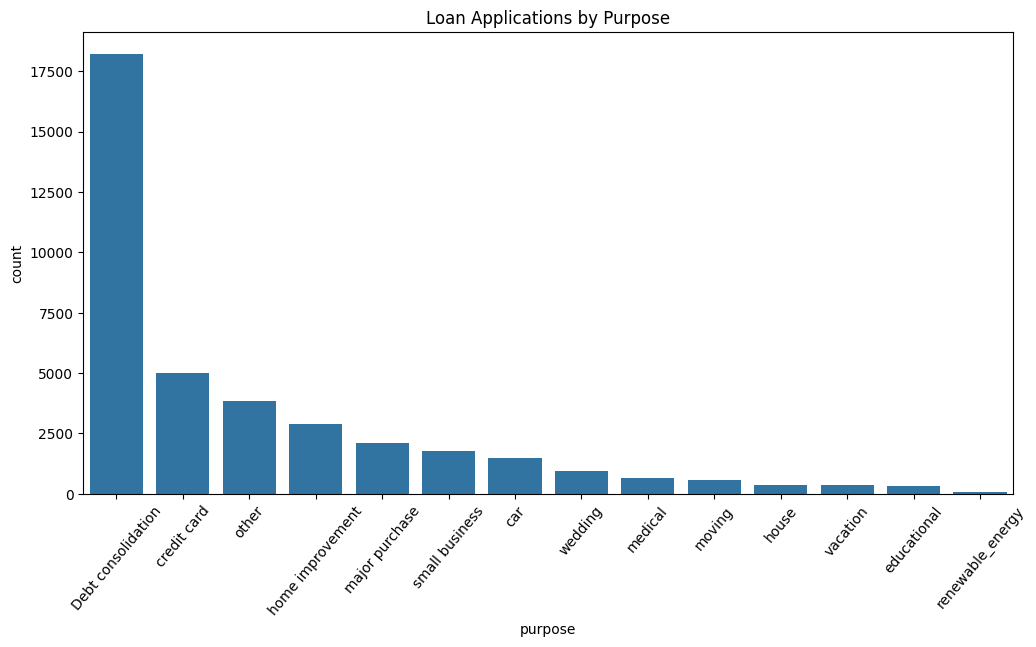

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='purpose', order=df['purpose'].value_counts().index)
plt.title('Loan Applications by Purpose')
plt.xticks(rotation=50)
plt.show()


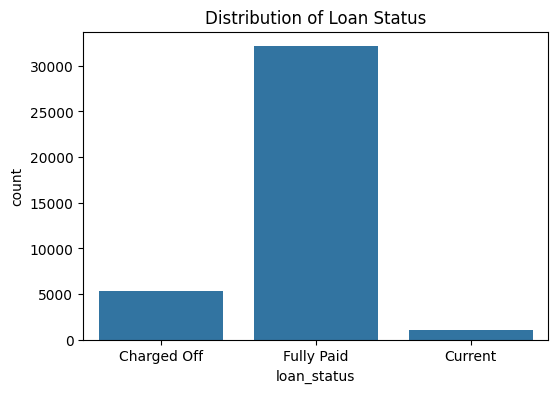

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='loan_status')
plt.title('Distribution of Loan Status')
plt.show()

In [ ]:
df['issue_date'] = pd.to_datetime(df['issue_date'], format='%d-%m-%Y')


df['issue_month'] = df['issue_date'].dt.month_name()
df['issue_year'] = df['issue_date'].dt.year

df['dti_category'] = pd.cut(df['dti'], bins=[0, 15, 25, 100], labels=['Low', 'Medium', 'High'])

In [ ]:
df.sample(3)

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment,issue_month,issue_year,dti_category
4243,645488,CA,INDIVIDUAL,10+ years,City of Redondo Beach,B,RENT,2021-01-11,16-05-2021,11-08-2021,...,64000.00,0.0756,462.09,0.0962,14400,36,15149,January,2021,Low
7302,543208,CA,INDIVIDUAL,2 years,UCSF,D,OWN,2021-07-10,16-05-2021,11-10-2021,...,36928.26,0.2437,272.62,0.1558,7800,11,4084,July,2021,Low
2683,858849,OH,INDIVIDUAL,3 years,Professional Support Inc,C,OWN,2021-08-11,15-11-2021,14-06-2021,...,50000.00,0.1171,205.04,0.1399,6000,22,7367,August,2021,Low


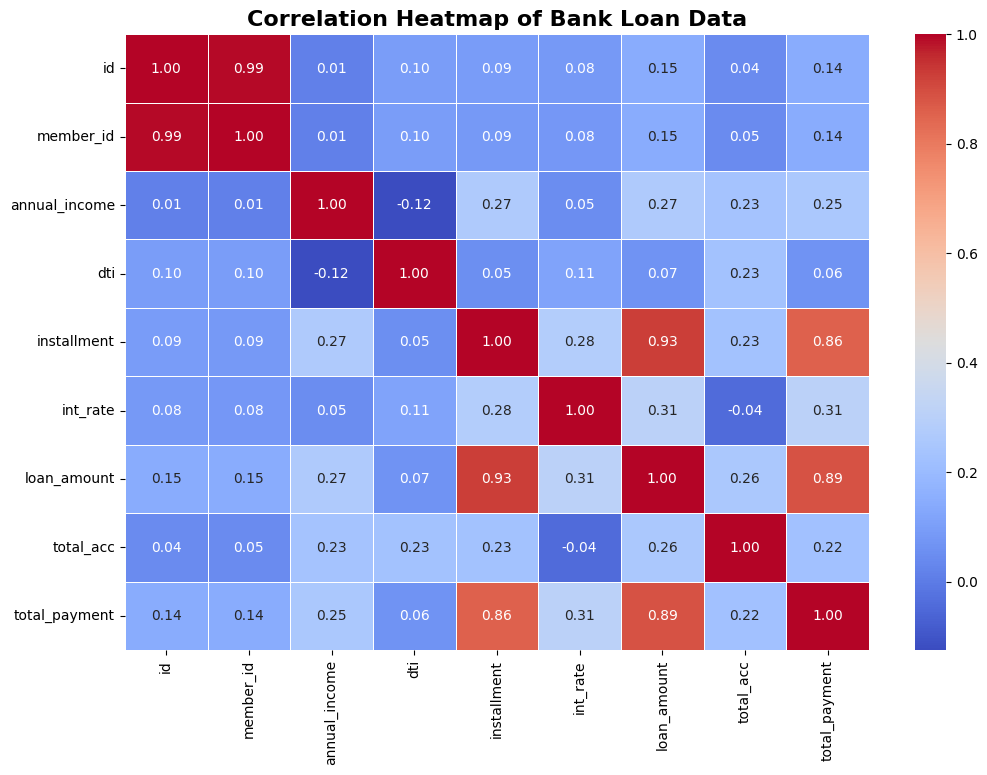

In [ ]:
numerical_cols = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numerical_cols.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)

plt.title('Correlation Heatmap of Bank Loan Data', fontsize=16, fontweight='bold')
plt.show()

Key Highlights of the Analysis:



1.   Data Readiness & Engineering: We effectively handled missing values, standardized the data structure, and engineered valuable new features such as issue_month, issue_year, and dti_category to enable deeper temporal and demographic analysis.

2.   SQL-Driven KPIs: We utilized SQL queries to aggregate and calculate critical business metrics, including Total Applications, Total Funded Amount, Total Amount Received, and Average Interest Rates.

3. Portfolio Health (Good vs. Bad Loans): We successfully segmented the dataset into "Good Loans" (Fully Paid/Current) and "Bad Loans" (Charged Off). Tracking the volume and funded amount of Bad Loans provides crucial visibility into the bank's financial risk.

4. Correlation & Trends: The correlation heatmap verified strong relationships between numerical variables like loan_amount, installment, and total_payment, ensuring the data is logical and ready for advanced modeling or visualization.





In [ ]:
df.to_csv('Cleaned_Bank_Loan_Data.csv', index=False)